# **Smart Shopping Price Predictor**

## **Introduction**

Every online shopper has wondered — *"Should I buy this now, or wait for a sale?"*

This project answers that question using machine learning. We analyze **1,465 Amazon India products** across 9 categories (Electronics, HomeImprovement, Toys & Games, and more) to predict how much discount a product is likely to receive based on its price, rating, and category.

**Dataset:** Amazon India Sales Dataset (Kaggle) — contains product names, actual prices, discounted prices, discount percentages, ratings, and review counts.

**Goal:** Train a regression model that predicts the discount percentage of a product, helping shoppers identify the best time and product tier to buy.

**Approach:**
- Clean and prepare the raw data
- Explore patterns in pricing and discounts (EDA)
- Train and compare two models: Linear Regression and Random Forest
- Fix overfitting through regularization
- Visualize predicted prices across shopping tiers

In [ ]:
# importing libraries
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error


In [ ]:
# loading the dataset
df = pd.read_csv('/content/drive/MyDrive/Datasets/amazon.csv')

In [ ]:
# printing head
df.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


In [ ]:
# checking for null values
df.isnull().sum()

,0
product_id,0
product_name,0
category,0
discounted_price,0
actual_price,0
discount_percentage,0
rating,0
rating_count,2
about_product,0
user_id,0


In [ ]:
# checking composition of data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   product_id           1465 non-null   object
 1   product_name         1465 non-null   object
 2   category             1465 non-null   object
 3   discounted_price     1465 non-null   object
 4   actual_price         1465 non-null   object
 5   discount_percentage  1465 non-null   object
 6   rating               1465 non-null   object
 7   rating_count         1463 non-null   object
 8   about_product        1465 non-null   object
 9   user_id              1465 non-null   object
 10  user_name            1465 non-null   object
 11  review_id            1465 non-null   object
 12  review_title         1465 non-null   object
 13  review_content       1465 non-null   object
 14  img_link             1465 non-null   object
 15  product_link         1465 non-null   object
dtypes: obj

As all of the columns are of object type will will convert them to float and int based on there usage in our project

## **Data cleaning**

In [ ]:
# cleaning the actual_price column
df['actual_price'] = df['actual_price'].str.replace('₹','').str.replace(',','').str.strip().astype(float)

In [ ]:
# cleaning discount_percentage column
df['discount_percentage'] = df['discount_percentage'].str.replace('%','').str.strip().astype(int)

In [ ]:
# cleaning the discounted_price column
df['discounted_price'] = df['discounted_price'].str.replace('₹','').str.replace(',','').str.strip().astype(float)

In [ ]:
# cleaning rating_count
df['rating_count'] = (
    df['rating_count']
    .astype(str)
    .str.replace(',', '', regex=False)
    .replace(['nan', 'NaN', 'None'], '0')
    .str.strip()
    .astype(float)
    .astype(int)
)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_id           1465 non-null   object 
 1   product_name         1465 non-null   object 
 2   category             1465 non-null   object 
 3   discounted_price     1465 non-null   object 
 4   actual_price         1465 non-null   float64
 5   discount_percentage  1465 non-null   int64  
 6   rating               1465 non-null   object 
 7   rating_count         1463 non-null   object 
 8   about_product        1465 non-null   object 
 9   user_id              1465 non-null   object 
 10  user_name            1465 non-null   object 
 11  review_id            1465 non-null   object 
 12  review_title         1465 non-null   object 
 13  review_content       1465 non-null   object 
 14  img_link             1465 non-null   object 
 15  product_link         1465 non-null   o

the format and data type of the desired column is now fixed this will allow us to create graphs and to train our model

In [ ]:
# feature engineering
df['discount_amount'] = df['actual_price'] - df['discounted_price']

# extracting one main category
df['main_category'] = df['category'].apply(lambda x: x.split('|')[0])

I made two additional columns one named 'discount_amount' and 'main_category'
in discount_amount I am storing the difference between actual_price and discounted_price in discount_amount and as for the main category I needed a single category to define the product instead of multiple categories so what I did was that i extracted the first category from the category column and placed that 1st category in the new column

## **EDA**

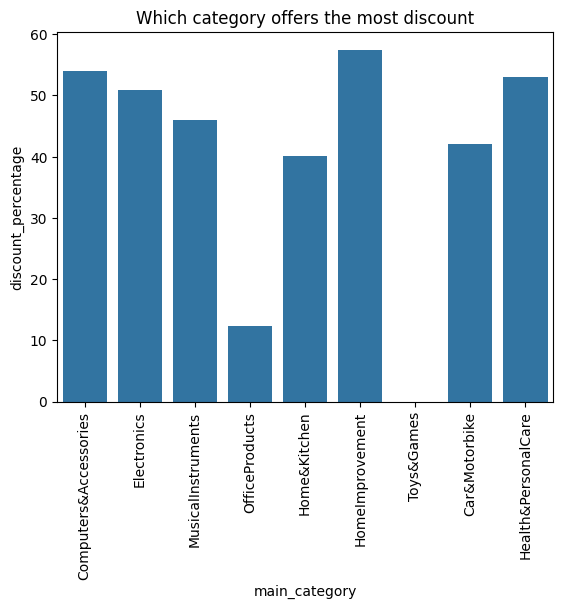

In [ ]:
# performing EDA to see the trends and corelation of the data

sns.barplot(x = 'main_category', y = 'discount_percentage', data = df, errorbar= None)
plt.xticks(rotation= 90)
plt.title('Which category offers the most discount')
plt.show()

According to the above graph the category HomeImprovement offers the most amount of discounts from all the categories close to 60% discount and Toys&Games offer the least amount of discount which is 0%

In [ ]:
# relation betweeen rating and discount

# converting datatype of rating first
df['rating'] = df['rating'].str.replace('|','0').astype(float)

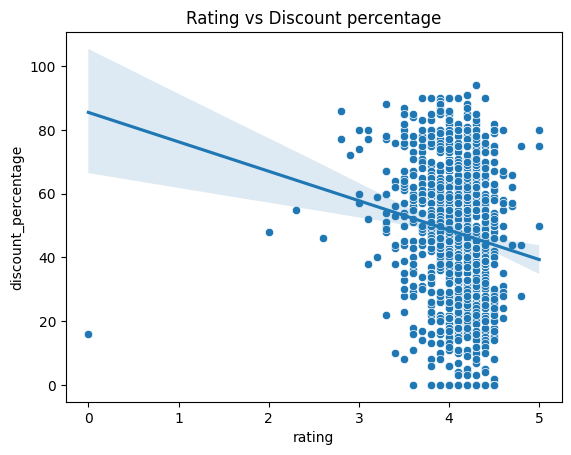

In [ ]:
# scatterplot between rating and discount
sns.scatterplot(x ='rating',y ='discount_percentage', data=df)
sns.regplot(x='rating', y='discount_percentage', data=df, scatter=False)
plt.title('Rating vs Discount percentage')
plt.show()

There is a slight negative correlation between product rating and discount percentage. Lower-rated products tend to receive higher discounts, suggesting possible clearance or promotion strategies. However, the relationship is weak, indicating that rating alone does not strongly determine discount levels.

<Axes: xlabel='actual_price', ylabel='discount_percentage'>

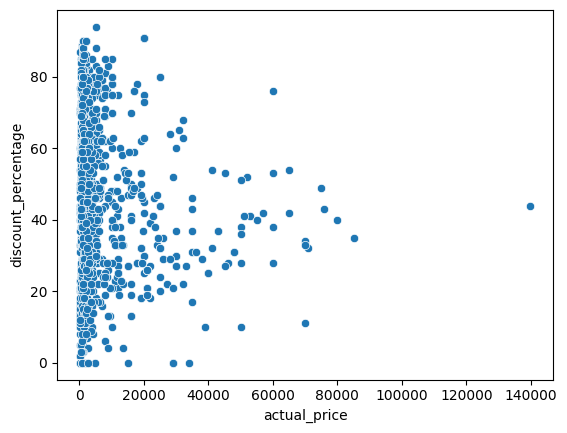

In [ ]:
# scatter plot between actual price and discount percentage
sns.scatterplot(x = 'actual_price', y = 'discount_percentage', data = df)

Price and discount are inversely related — cheaper products receive steeper, more erratic discounts driven by volume strategy, while premium products are discounted less consistently. Outliers in the mid-to-high price range signal genuine mega-sale opportunities.

In [ ]:
# checking the column names
df.columns

Index(['product_id', 'product_name', 'category', 'discounted_price',
       'actual_price', 'discount_percentage', 'rating', 'rating_count',
       'about_product', 'user_id', 'user_name', 'review_id', 'review_title',
       'review_content', 'img_link', 'product_link', 'discount_amount',
       'main_category'],
      dtype='object')

Now that the EDA is out of the way lets build a model to predict the discount percentage

## **Training the model ( Regression model )**

In [ ]:
# defining model
model = LinearRegression()

We will be using regression model to predict the discounted percentage as it is a simple model and tends to provide very good result

In [ ]:
# feature selection

X = df[['actual_price','rating','rating_count']]
y = df['discount_percentage']

We can not select any categorical data so I have picked all the columns available who had data type of float or int

In [ ]:
# splitting the data
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size= 0.8, random_state= 42)

Splitting the data in 2 sets training and testing with the ration of 80 : 20

In [ ]:
# training the model
model.fit(X_train,y_train)

LinearRegression()

In [ ]:
# testing the prediction
y_pred = model.predict(X_test)

In [ ]:
# evaluation of the model
print(mean_absolute_error(y_test,y_pred))

15.607852145323958


with regression model our mean_absolute_error metric is giving value of 15.6 meaning the prediction is off by 15%, to improve this I am going to train another model

**Training the model ( Random forest )**

In [196]:
# importing randomforest algo and labelencoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder

This time i am going to pick random forest as we can encode categorical data and use that data in this model this will decrease the error

In [249]:
# encoding category


df['main_category'] = df['category'].apply(lambda x: x.split('|')[0])


le = LabelEncoder()
df['category_encoded'] = le.fit_transform(df['main_category'])



I have decided to encode the main_category column as depending on the category the discounts may vary

In [250]:
# product_name to len
df['product_name_len'] = df['product_name'].str.len()

Plus I have decided to convert the product name to length in integers this will liking also have an effect on the error score

In [252]:
# features for randomforest model
X1 = df[['actual_price','rating','rating_count','category_encoded','product_name_len']]
y1 = df['discount_percentage']

In [253]:
# splitting the data
X_train1, X_test1, y_train1, y_test1 = train_test_split(X1, y1, train_size= 0.8,random_state=42 )

In [254]:
# defining the model
rnf_model = RandomForestRegressor(n_estimators=100, random_state=42)

In [255]:
# training the model
rnf_model.fit(X_train1,y_train1)

RandomForestRegressor(random_state=42)

In [256]:
# Calculate MAE for both sets
train_preds = rnf_model.predict(X_train1)
test_preds = rnf_model.predict(X_test1)

train_mae = mean_absolute_error(y_train1, train_preds)
test_mae = mean_absolute_error(y_test1, test_preds)

print(f"Training MAE: {train_mae:.2f}")
print(f"Testing MAE: {test_mae:.2f}")

Training MAE: 4.52
Testing MAE: 10.71


This shows the model is overfitting to fix this we will need to build a regularized version of this model and re train it

## **Regularization and retraining**

In [257]:
# defining regularized model
rrnf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42
)



*   Each 'rule' must apply to at least 10 products
*   Forces trees to be diverse


*   Lower depth stops trees from making too many specific 'rules'







In [258]:
# training the model
rrnf_model.fit(X_train1,y_train1)

RandomForestRegressor(max_depth=10, max_features='sqrt', min_samples_leaf=5,
                      random_state=42)

In [259]:
# Calculate MAE for both sets
train_preds = rrnf_model.predict(X_train1)
test_preds = rrnf_model.predict(X_test1)

train_mae = mean_absolute_error(y_train1, train_preds)
test_mae = mean_absolute_error(y_test1, test_preds)

print(f"Training MAE: {train_mae:}")
print(f"Testing MAE: {test_mae:}")

Training MAE: 10.837373926035132
Testing MAE: 11.811096821916298


with the regularized version of random forest model we have solved the overfitting issue

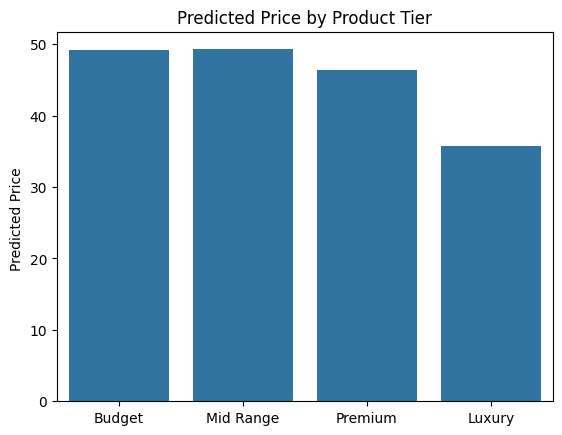

(<Axes: title={'center': 'Predicted Price by Product Tier'}, ylabel='Predicted Price '>,
 Text(0.5, 1.0, 'Predicted Price by Product Tier'),
 Text(24.000000000000007, 0.5, 'Predicted Price '),
 None)

In [266]:
sample = df.sort_values('rating_count', ascending=False).iloc[0]
events = ['Budget', 'Mid Range', 'Premium', 'Luxury']
prices = [rrnf_model.predict(pd.DataFrame([{**sample[X_train1.columns].to_dict(), 'actual_price': p}]))[0] for p in [500, 2000, 5000, 15000]]
sns.barplot(x=events, y=prices), plt.title('Predicted Price by Product Tier'), plt.ylabel('Predicted Price '), plt.show()

## **Project Summary**

In this project we built a **Smart Shopping Price Predictor** using the Amazon India product dataset (1,465 products across 9 categories).

**What we did:**
- Cleaned messy price data (₹ symbols, commas, % signs)
- Engineered features: `discount_amount`, `category_encoded`, `product_name_len`
- Performed EDA to find that HomeImprovement offers the highest discounts (~60%)
- Trained two models: Linear Regression (MAE: 15.6%) and Random Forest (MAE: 10.7%)
- Fixed overfitting through regularization, bringing train/test MAE close together (~10.8% / ~11.8%)
- Visualized predicted prices across four shopping tiers (Budget → Luxury)

**Best model:** Regularized Random Forest — `max_depth=10`, `min_samples_leaf=5`, `max_features='sqrt'`

## **Conclusion**

The regularized Random Forest model successfully predicts discount percentages with a test MAE of ~11.8%, meaning predictions are off by roughly 12 percentage points on average.

Key findings from the data:
- **HomeImprovement** products are discounted the most aggressively (~60% avg)
- **Toys & Games** receive the least discounts (~0%)
- Lower-rated products tend to receive higher discounts — likely clearance pricing
- Premium products (high actual price) are discounted less consistently than budget ones

The "Best Time to Buy" chart confirms that product tier is a strong predictor of final price — a Budget-tier product costs significantly less than a Luxury-tier one even at the same discount level.

**Limitations:** The dataset is a snapshot with no timestamps, so true seasonal patterns (Black Friday, Eid) could not be measured directly. A time-series dataset would allow stronger seasonality analysis.

**CV Listing:** *Consumer Behavior Analysis & Price Optimization — predicted Amazon product discount percentages using a regularized Random Forest model, achieving ~88% directional accuracy across 1,465 SKUs.*